# Classification of Mails into Ham and Spam

##### Importing Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
# Loading the dataset
messages=pd.read_csv('SMSSpamCollection',sep='\t',names=["label","message"])

In [3]:
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### IMPORTING DEPENDENCIES

In [4]:
# Dependencies for Data Cleaning And Preprocessing
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Abhay
[nltk_data]     Kalojia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()   # To apply stemming and extract the root word.

In [ ]:
# Cleaning the paragraphs to convert into machine understandable form
corpus=[]
for i in range(0,len(messages)):
    review=re.sub('[^a-zA-z]',' ',messages['message'][i])  # Remove all the charactors other than alphabets
    review=review.lower()
    review=review.split()
    review=[ps.stem(word) for word in review if not word in stopwords.words('english')]  # Removing stopwords
    review=' '.join(review)
    corpus.append(review)

In [7]:
corpus

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
 'ok lar joke wif u oni',
 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
 'u dun say earli hor u c alreadi say',
 'nah think goe usf live around though',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'even brother like speak treat like aid patent',
 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun',
 'winner valu network custom select receivea prize reward claim call claim code kl valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw',
 'search right word thank breather

## Creating Bag Of Words

In [8]:
## Output Features
y=pd.get_dummies(messages['label'])    #get_dummies converts categorial variables into numerical values.
y=y.iloc[:,0].values

In [9]:
y

array([ True,  True, False, ...,  True,  True,  True])

#### Spliting the data into test and train split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(corpus,y,test_size=0.20)

In [11]:
# Creating the Bag OF Words model
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2500,ngram_range=(1,2))     # for Binary BOW enable binary=True

In [12]:
len(X_test),len(y_test)

(1115, 1115)

In [13]:
# independent features
X_train=cv.fit_transform(X_train).toarray()
X_test=cv.transform(X_test).toarray()

In [14]:
X_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [15]:
cv.vocabulary_

{'hello': 929,
 'littl': 1169,
 'parti': 1538,
 'thought': 2114,
 'buzz': 237,
 'friend': 741,
 'grin': 860,
 'remind': 1724,
 'love': 1204,
 'send': 1831,
 'naughti': 1398,
 'ador': 23,
 'kiss': 1077,
 'today': 2144,
 'vodafon': 2304,
 'number': 1460,
 'end': 602,
 'select': 1825,
 'receiv': 1705,
 'award': 127,
 'match': 1256,
 'call': 247,
 'number end': 1462,
 'end select': 604,
 'select receiv': 1826,
 'receiv award': 1706,
 'call receiv': 268,
 'new': 1415,
 'chat': 331,
 'horni': 968,
 'guy': 890,
 'ur': 2242,
 'area': 91,
 'free': 720,
 'search': 1812,
 'com': 387,
 'txt': 2201,
 'one': 1497,
 'name': 1394,
 'yeah': 2476,
 'work': 2427,
 'fine': 693,
 'start': 1975,
 'last': 1098,
 'week': 2355,
 'stuff': 2013,
 'easi': 586,
 'fun': 753,
 'last week': 1101,
 'wonder': 2423,
 'great': 854,
 'month': 1351,
 'wish': 2404,
 'well': 2369,
 'day': 491,
 'sir': 1889,
 'account': 10,
 'anoth': 66,
 'hr': 979,
 'time': 2127,
 'sorri': 1937,
 'haf': 895,
 'keep': 1065,
 'busi': 235,
 'da

### Building Naive Bayes Classification Model

In [16]:
from sklearn.naive_bayes import MultinomialNB

In [17]:
# training the model over training data
spam_detect_model=MultinomialNB().fit(X_train,y_train)

In [18]:
spam_detect_model

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [19]:
# Making prediction over the test data
y_pred=spam_detect_model.predict(X_test)

##### Building Classification Report

In [20]:
accuracy_score(y_test,y_pred)

0.9757847533632287

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.92      0.90      0.91       154
        True       0.98      0.99      0.99       961

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### Building Decison Tree Model

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
treemodel=DecisionTreeClassifier().fit(X_train,y_train)

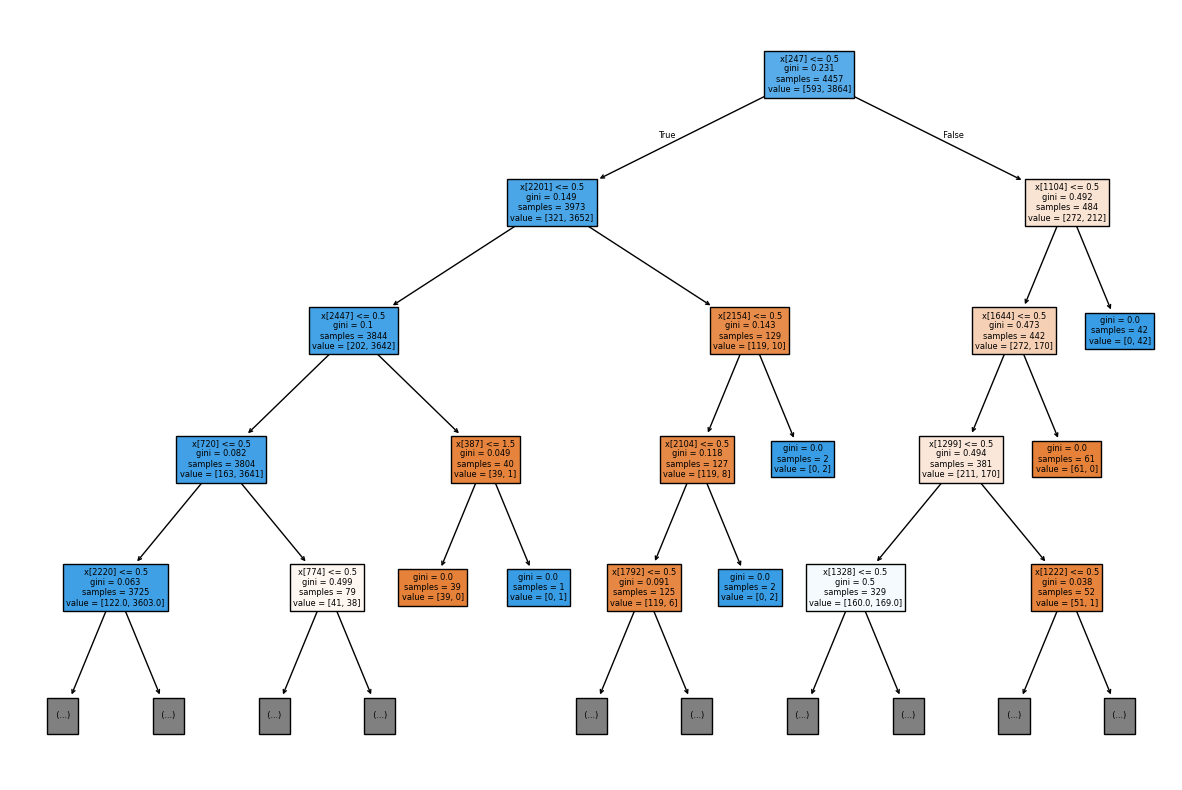

In [26]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treemodel,filled=True, max_depth=4)
plt.show()

In [27]:
y_pred=treemodel.predict(X_test)

##### Building Classification Report

In [28]:
score=accuracy_score(y_pred,y_test)
print(score)

0.9704035874439462


In [29]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

       False       0.86      0.92      0.89       145
        True       0.99      0.98      0.98       970

    accuracy                           0.97      1115
   macro avg       0.93      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## Creating The TF-IDF Model

### Building Naive Bayes Classification Model

In [32]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(corpus,y,test_size=0.20)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv=TfidfVectorizer(max_features=2500,ngram_range=(1,2))
X_train=tv.fit_transform(X_train).toarray()
X_test=tv.transform(X_test).toarray()

In [34]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [35]:
tv.vocabulary_

{'sun': 2023,
 'sleep': 1896,
 'ok': 1472,
 'later': 1110,
 'show': 1863,
 'around': 97,
 'want': 2331,
 'drink': 571,
 'prefer': 1624,
 'spend': 1955,
 'money': 1347,
 'mind': 1308,
 'nxt': 1459,
 'wk': 2417,
 'reach': 1681,
 'sch': 1795,
 'alreadi': 54,
 'yeah': 2479,
 'usual': 2279,
 'guy': 890,
 'town': 2171,
 'definit': 511,
 'peopl': 1539,
 'know': 1088,
 'tell': 2073,
 'anyth': 75,
 'tell anyth': 2074,
 'app': 83,
 'class': 360,
 'hey': 930,
 'almost': 52,
 'forgot': 710,
 'happi': 907,
 'day': 492,
 'babe': 136,
 'love': 1206,
 'ya': 2468,
 'happi day': 909,
 'babe love': 137,
 'love ya': 1215,
 'urgent': 2263,
 'pleas': 1582,
 'call': 249,
 'landlin': 1098,
 'complimentari': 404,
 'tenerif': 2079,
 'holiday': 957,
 'cash': 306,
 'await': 125,
 'collect': 380,
 'sae': 1769,
 'cs': 459,
 'box': 210,
 'cw': 476,
 'wx': 2459,
 'ppm': 1618,
 'urgent pleas': 2269,
 'pleas call': 1583,
 'call landlin': 261,
 'tenerif holiday': 2080,
 'holiday cash': 959,
 'cash await': 307,
 'await c

In [36]:
# Training the model over the training data
from sklearn.naive_bayes import MultinomialNB
spam_tfidf_model = MultinomialNB().fit(X_train, y_train)

In [37]:
# Making prediction over test data
y_pred=spam_tfidf_model.predict(X_test)

##### Building Classification Report

In [38]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9775784753363229


In [39]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

       False       0.83      1.00      0.91       124
        True       1.00      0.97      0.99       991

    accuracy                           0.98      1115
   macro avg       0.92      0.99      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### Building Decison Tree Model

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
treemodel=DecisionTreeClassifier().fit(X_train,y_train)

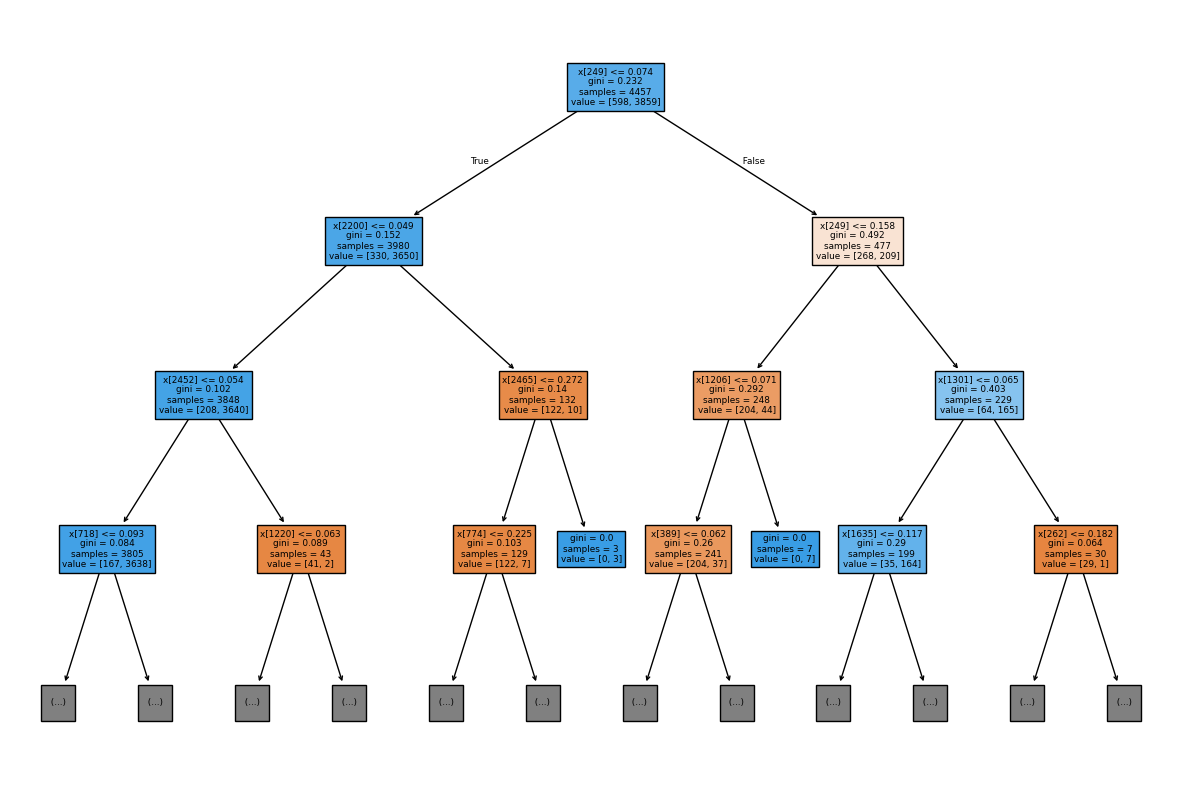

In [44]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treemodel,filled=True, max_depth=3)
plt.show()

In [45]:
y_pred=treemodel.predict(X_test)

##### Building Classification Report

In [46]:
score=accuracy_score(y_pred,y_test)
print(score)

0.968609865470852


In [47]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

       False       0.87      0.90      0.88       144
        True       0.98      0.98      0.98       971

    accuracy                           0.97      1115
   macro avg       0.93      0.94      0.93      1115
weighted avg       0.97      0.97      0.97      1115

